In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier , RandomForestClassifier
from sklearn.preprocessing import StandardScaler ,  LabelEncoder
from sklearn.metrics import accuracy_score ,  precision_score , recall_score
data=pd.read_csv(r"C:\Users\BHIMA SHANKAR\Downloads\customer_analytics.csv")
data.head(1000)

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
251,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
252,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743
253,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


In [4]:
data.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [5]:
data["Age"].count()

np.int64(255)

In [7]:
data["City"].value_counts()

City
Chennai      49
Pune         48
Bangalore    41
Hyderabad    40
Delhi        40
Mumbai       37
Name: count, dtype: int64

In [9]:
data.shape

(255, 14)

In [10]:
data.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


In [13]:
threshold = len(data) * 0.5
data= data.dropna(thresh=threshold, axis=1)
data

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
251,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
252,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743
253,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526


In [18]:
for col in data.select_dtypes(include=np.number):
    data[col].fillna(data[col].mean(), inplace=True)
for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode()[0], inplace=True)

C:\Users\BHIMA SHANKAR\AppData\Local\Temp\ipykernel_4420\3267293600.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)
C:\Users\BHIMA SHANKAR\AppData\Local\Temp\ipykernel_4420\3267293600.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [21]:
data.duplicated().sum()

np.int64(5)

In [23]:
data = data.drop_duplicates()
data

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1246,26,Female,Mumbai,PhD,Single,80802.0,24,1,19,25,2,Tablet,2453
246,1247,30,Female,Mumbai,PhD,Single,72973.0,40,10,23,11,2,Desktop,4476
247,1248,41,Male,Delhi,Masters,Single,55817.0,61,21,16,9,3,Laptop,1108
248,1249,24,Female,Mumbai,PhD,Single,39314.0,65,1,4,22,3,Laptop,3802


In [24]:
data.duplicated().sum()

np.int64(0)

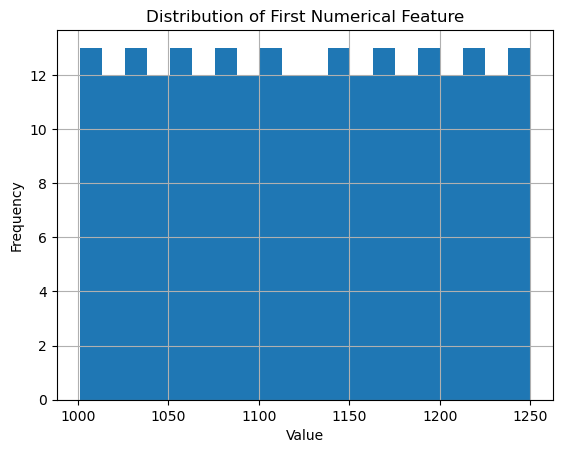

In [25]:
plt.figure()
data.select_dtypes(include=np.number).iloc[:,0].hist(bins=20)
plt.title("Distribution of First Numerical Feature")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

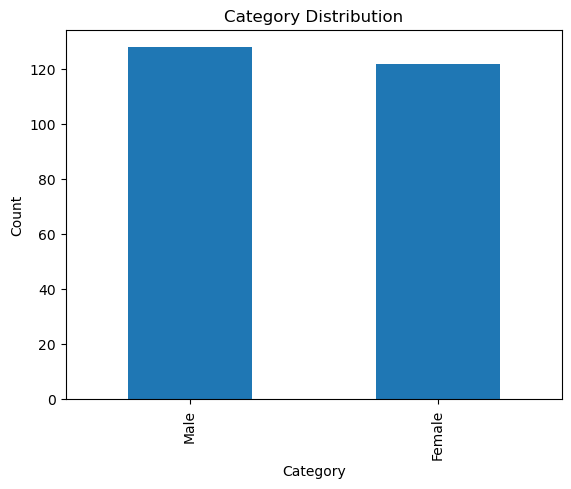

In [28]:
plt.figure()
data.select_dtypes(include='object').iloc[:,0].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

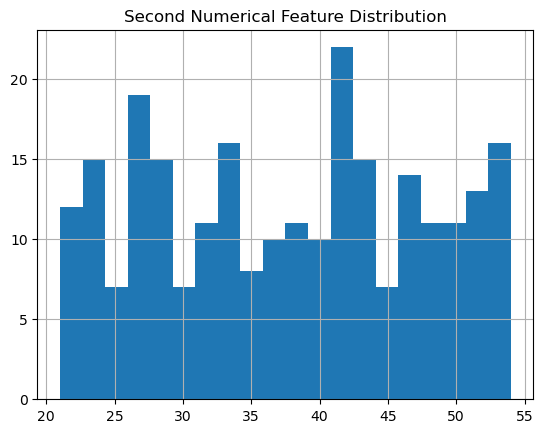

In [29]:
plt.figure()
data.select_dtypes(include=np.number).iloc[:,1].hist(bins=20)
plt.title("Second Numerical Feature Distribution")
plt.show()

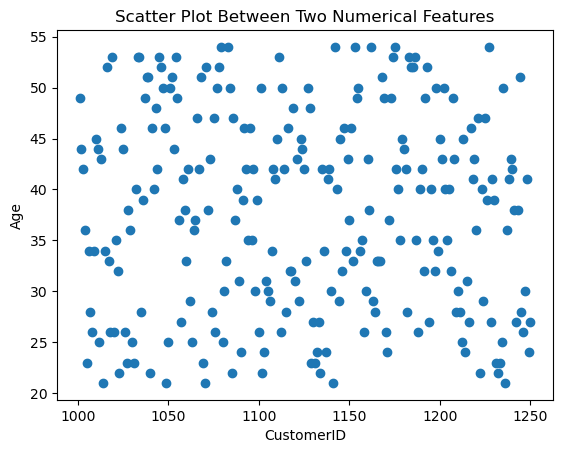

In [30]:
num_cols = data.select_dtypes(include=np.number).columns

plt.figure()
plt.scatter(data[num_cols[0]], data[num_cols[1]])
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.title("Scatter Plot Between Two Numerical Features")
plt.show()

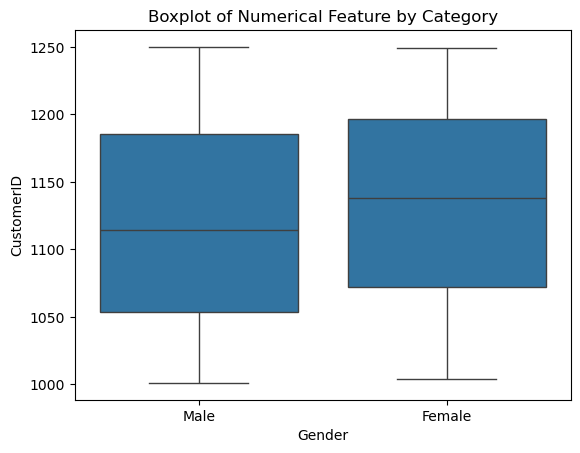

In [32]:
cat_col = data.select_dtypes(include='object').columns[0]
num_col = data.select_dtypes(include=np.number).columns[0]

plt.figure()
sns.boxplot(x=data[cat_col], y=data[num_col])
plt.title("Boxplot of Numerical Feature by Category")
plt.show()

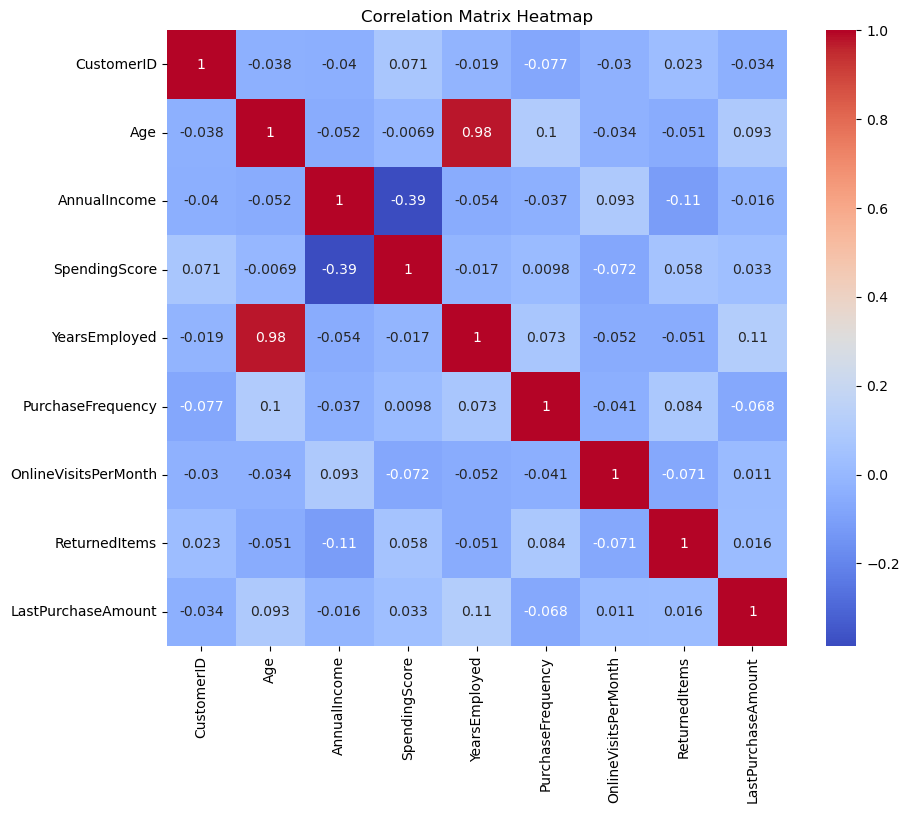

In [33]:
plt.figure(figsize=(10,8))
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()